<a href="https://colab.research.google.com/github/xr-cc/DSCoV-Workshop-on-Topic-Modeling/blob/main/topic_modeling_NLP_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Topic Modeling Demo 1 (NLP)
In this notebook, we will see how topic modeling methods LDA and NMF can be applied onto a real-word text dataset.

The dataset is downloaded from [EurekAlert!: An open dataset for science communication research](https://dataverse.nl/dataset.xhtml?persistentId=doi:10.34894/EZO4JE).
The dataset spans from the inception of the **EurekAlert!** platform in January 1996 through March 2025, encompassing a total of 566,566 press releases.

> "EurekAlert! is an online science news service featuring health, medicine, science and technology news from leading research institutions and universities. Sponsored by AAAS, the science society."

**Reference**

Zhang, Jingwen; Jonathan Dudek; Alysson Mazoni; Enrique Orduna-Malea; Rodrigo Costas, 2025, "EurekAlert!: An open dataset for science communication research", https://doi.org/10.34894/EZO4JE, DataverseNL, V2

Install package `ijson` to load large JSON files.

In [2]:
!pip install ijson

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.0/149.0 kB 4.8 MB/s eta 0:00:00


Import packages

In [101]:
import numpy as np
import pandas as pd
import ijson

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.decomposition import LatentDirichletAllocation, NMF
import re
from wordcloud import WordCloud, STOPWORDS

from google.colab import drive
# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load data

In [102]:
# Load the JSON file from Google Drive
file_path = '/content/drive/MyDrive/DSCoV_Workshop/EurekAlert_dataset_2025.json' # Update the path if needed
# For large json files, only load a subset of items
n_items = 10000
items = []
with open(file_path, 'r') as f:
    parser = ijson.items(f, 'item')
    for i, item in enumerate(parser):
        if i >= n_items:  # stop after n_items
            break
        items.append(item)
print(len(items), "items loaded")
df = pd.DataFrame(items) # If want to subset to a specific journal: df = df[df['journal']=='Science']
display(df.head())

10000 items loaded


,euid,eurekalert_link,doi,title,description,keywords,funder,journal,type,institution,meeting,post_time,original_source,keywords_seq,instition_seq,fulltext_url
0,656735,http://www.eurekalert.org/news-releases/656735,None,Sperm study reveals testes cells that may offe...,Scientists have discovered a tiny group of cel...,"Stem cells/Life sciences/Cell biology/Cells/,C...",European Research Council,Journal of Experimental Medicine,Peer-Reviewed Publication,University of Edinburgh,None,2017-05-04T00:00:00,http://www.ed.ac.uk/news/2017/sperm-study-fert...,"[{'keywords_seq_1': '3', 'keywords_seq_2': '2'...","[{'institution_seq': '1', 'institution_id': '1...",[]
1,656736,http://www.eurekalert.org/news-releases/656736,None,"In groundbreaking research, Yale and Salk Inst...",Researchers at Yale and the Salk Institute hav...,Cell junctions/Life sciences/Cell biology/Cell...,None,Science,Peer-Reviewed Publication,Yale University,None,2001-11-22T00:00:00,None,"[{'keywords_seq_1': '2', 'keywords_seq_2': '1'...","[{'institution_seq': '1', 'institution_id': '2...",[]
2,656737,http://www.eurekalert.org/news-releases/656737,None,NIST/CU 'star comb' joins quest for Earth-like...,"If there is life on other planets, a laser fre...",Infrared astronomy/Physical sciences/Physics/A...,National Institute of Standards and Technology...,Optics Express,Peer-Reviewed Publication,National Institute of Standards and Technology...,None,2012-03-07T00:00:00,None,"[{'keywords_seq_1': '2', 'keywords_seq_2': '1'...","[{'institution_seq': '1', 'institution_id': '2...",[]
3,656738,http://www.eurekalert.org/news-releases/656738,None,Ratification of human rights treaties makes no...,A paper in this week's edition of the Lancet c...,"Medical economics/Social sciences/Economics/,H...",None,The Lancet,Peer-Reviewed Publication,The Lancet_DELETED,None,2009-06-04T00:00:00,None,"[{'keywords_seq_1': '2', 'keywords_seq_2': '1'...","[{'institution_seq': '1', 'institution_id': '1...","[{'url_seq': '2', 'url_id': '215454', 'fulltex..."
4,656740,http://www.eurekalert.org/news-releases/656740,None,Discovery reveals how the body regulates blood...,"A team of UK researchers, led by a Cardiff Uni...",Enzymes/Life sciences/Biochemistry/Biomolecule...,None,Science,Peer-Reviewed Publication,Cardiff University,None,2004-11-15T00:00:00,None,"[{'keywords_seq_1': '2', 'keywords_seq_2': '4'...","[{'institution_seq': '1', 'institution_id': '1...",[]


In [103]:
# Define a list of additional stop words and terms to remove
additional_stop_words = ['university', 'new', 'research', 'study', 'paper', 'science', 'scientists', 'researchers', 'institute', 'journal',
                         'publish', 'published', 'national', 'world', 'developed', 'team', 'today', 'people', 'help', 'used', 'use',
                         'using', 'development', 'results', 'shows', 'show', 'develop', 'according', 'find', 'found', 'will', 'may']
all_stop_words = list(ENGLISH_STOP_WORDS) + additional_stop_words

# Create a CountVectorizer with custom stop words and token pattern to remove numbers and short terms,
# keeping tokens that contain only letters and are at least 2 characters long.
# Also keeps only the words that appear in at least 15 documents (rare words),
# and removes words that appear in more than 50% of all documents (too common words).
vectorizer = CountVectorizer(max_df=0.5, min_df=15, stop_words=all_stop_words, token_pattern=r"(?u)\b[a-zA-Z]{2,}\b")

# Generate the document-word matrix from the 'title' and 'description' column
documents = (df['title']+' '+df['description']).astype(str).values
doc_word_matrix = vectorizer.fit_transform(documents)
print("Doc-Word matrix size:", doc_word_matrix.shape)

# Convert the matrix to a DataFrame
doc_word_df_filtered = pd.DataFrame(doc_word_matrix.toarray(), columns=vectorizer.get_feature_names_out())

# Display the first few rows of the filtered document-word matrix DataFrame
display(doc_word_df_filtered.head())

Doc-Word matrix size: (10000, 3353)


,aaas,abilities,ability,able,abnormal,abnormalities,aboard,absence,abundant,abuse,...,yesterday,yield,yields,york,young,younger,youth,zealand,zone,zurich
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [105]:
# List 10 most frequent words in the filtered corpus.
display(doc_word_df_filtered.sum(axis=0).sort_values(ascending=False).head(10))

,0
cancer,2039
patients,1424
disease,1394
health,1382
cells,1205
risk,1196
brain,1001
treatment,826
children,821
medicine,801


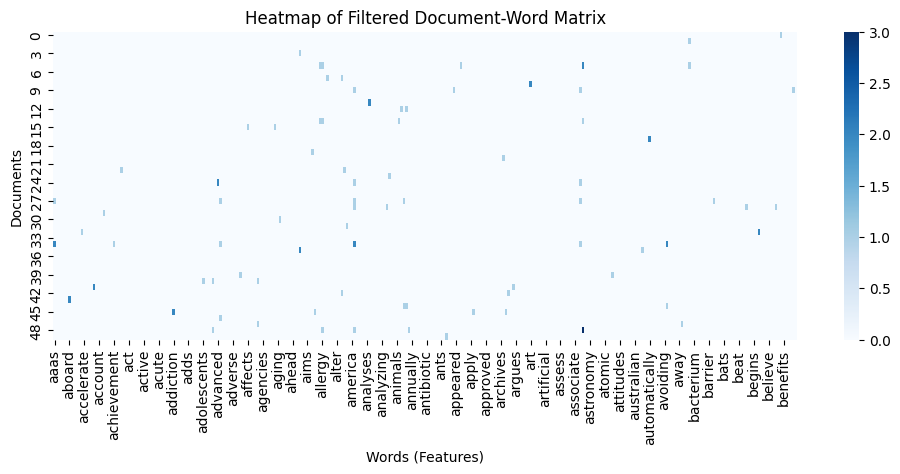

In [106]:
# Plot the heatmap of the filtered document-word matrix DataFrame
# for the subset of first 50 documents and first 300 words.
plt.figure(figsize=(12, 4))
sns.heatmap(doc_word_df_filtered.iloc[0:50][doc_word_df_filtered.columns[:300]].astype(int), cmap='Blues') # You can choose a different colormap
plt.title('Heatmap of Filtered Document-Word Matrix')
plt.xlabel('Words (Features)')
plt.ylabel('Documents')
plt.show()

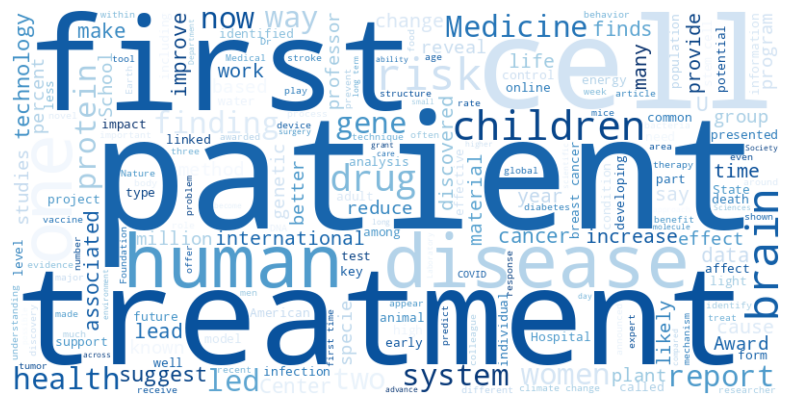

In [107]:
# Create a WordCloud object for the fileterd documents
all_documents = " ".join(documents)
stopwords = STOPWORDS.union(additional_stop_words)
wordcloud = WordCloud(width=800, height=400, background_color='white',colormap='Blues', stopwords=stopwords).generate(all_documents)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

## Perform topic modeling via LDA

In [122]:
# Define the number of topics
n_topics = 4

# Create an LDA model
lda = LatentDirichletAllocation(n_components=n_topics, random_state=0)

# Fit the model to the filtered document-word matrix
lda.fit(doc_word_df_filtered)

# Get the document-topic distribution for each document
Phi = lda.transform(doc_word_df_filtered)

# Display the top words for each topic (optional)
feature_names = doc_word_df_filtered.columns
Theta = lda.components_
for topic_idx, topic in enumerate(Theta):
    top_words_idx = topic.argsort()[:-10 - 1:-1] # Get indices of top 10 words
    top_words = [feature_names[i] for i in top_words_idx]
    print(f"Topic #{topic_idx+1}: {' '.join(top_words)}")

Topic #1: cancer patients disease cells risk treatment heart drug blood cell
Topic #2: brain children change human climate health species likely women years
Topic #3: energy light nasa way technology water earth high carbon tropical
Topic #4: health million care professor american society award grant medical center


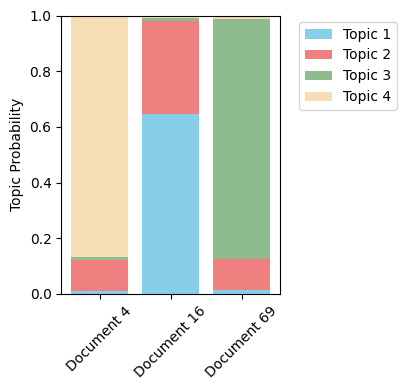

In [123]:
# Select a few document indices to visualize
selected_indices = [3, 15, 68]

# Get the document-topic vectors for the selected documents
selected_vectors = Phi[selected_indices]

# Define colors for each topic
colors = ['skyblue', 'lightcoral', 'darkseagreen', 'wheat'] # Make sure there enough colors for topics

# Plot the stacked bar charts for document-topic vectors
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3,4))
for i, doc_index in enumerate(selected_indices):
    topic_probabilities = selected_vectors[i]
    bottom = 0
    for topic_idx, prob in enumerate(topic_probabilities):
        ax.bar(i, prob, bottom=bottom, color=colors[topic_idx], label=f'Topic {topic_idx+1}')
        bottom += prob
ax.set_xticks(np.arange(len(selected_indices)))
ax.set_xticklabels([f'Document {i+1}' for i in selected_indices], rotation=45)
ax.set_ylabel('Topic Probability')
ax.set_ylim(0, 1)
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles[:n_topics], labels[:n_topics], loc='upper left', bbox_to_anchor=(0.99, 0.95))
plt.tight_layout()
plt.show()

In [124]:
# Print the selected documents
print("=== Selected Documents ===")
for i, doc_index in enumerate(selected_indices):
    print(f"Document {doc_index+1}: {documents[doc_index]}\n")

=== Selected Documents ===
Document 4: Ratification of human rights treaties makes no difference to health status A paper in this week's edition of the Lancet concludes that whether or not a country has ratified UN human rights treaties has no effect on the health status of its population. This health policy paper is written by Dr. Edward J. Mills from the British Columbia Center for Excellence in HIV/AIDS, Vancouver, Canada, and colleagues.

Document 16: A step forward in the struggle against neuroblastoma, a type of childhood cancer A protein called CD44 makes it possible to identify the population of mother cells that are responsible for the aggressive nature and low survival rate of neuroblastoma, a type of childhood cancer that mainly affects children of two and three years old.

Document 69: UNH scientist: Cosmic rays threaten future deep-space astronaut missions Crewed missions to Mars remain an essential goal for NASA, but scientists are only now beginning to understand and cha

## Perform topic modeling via NMF

In [116]:
# Define the number of topics
n_topics = 4

# Create an NMF model
nmf = NMF(n_components=n_topics, random_state=1)

# Fit the model to the filtered document-word matrix
nmf.fit(doc_word_df_filtered)

# Get the document-topic distribution for each document
H = nmf.transform(doc_word_df_filtered)

# Display the top words for each topic (optional)
W = nmf.components_
for topic_idx, topic in enumerate(W):
    top_words_idx = topic.argsort()[:-10 - 1:-1] # Get indices of top 10 words
    top_words = [feature_names[i] for i in top_words_idx]
    print(f"Topic #{topic_idx+1}: {', '.join(top_words)}")


Topic #1: cancer, breast, center, patients, treatment, prostate, women, lung, therapy, drug
Topic #2: disease, patients, risk, heart, blood, treatment, women, high, associated, alzheimer
Topic #3: cells, cell, brain, stem, human, protein, immune, blood, gene, discovered
Topic #4: health, children, care, million, school, medicine, public, medical, center, grant


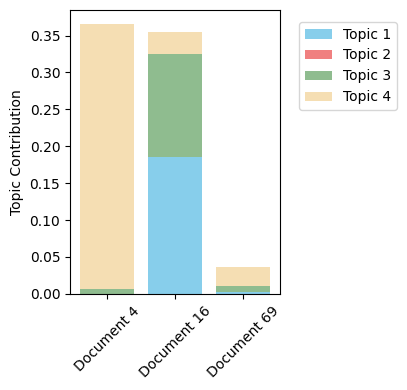

In [119]:
# Select a few document indices to visualize
selected_indices = [3, 15, 68]

# Get the document-topic vectors for the selected documents
selected_vectors = H[selected_indices]

# Define colors for each topic
colors = ['skyblue', 'lightcoral', 'darkseagreen', 'wheat']

# Plotting the stacked bar charts
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3,4))

for i, doc_index in enumerate(selected_indices):
    topic_contributions = selected_vectors[i]
    bottom = 0
    for topic_idx, prob in enumerate(topic_contributions):
        ax.bar(i, prob, bottom=bottom, color=colors[topic_idx], label=f'Topic {topic_idx+1}')
        bottom += prob
ax.set_xticks(np.arange(len(selected_indices)))
ax.set_xticklabels([f'Document {i+1}' for i in selected_indices], rotation=45)
ax.set_ylabel('Topic Contribution')

# Add a legend
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles[:n_topics], labels[:n_topics], loc='upper left', bbox_to_anchor=(0.99, 0.95))
plt.tight_layout()
plt.show()

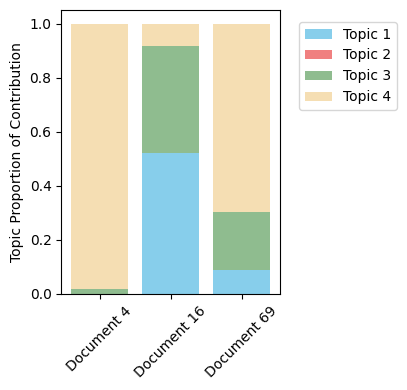

In [120]:
# Select three document indices (you can change these)
selected_indices = [3, 15, 68]

# Get the document-topic vectors for the selected documents
selected_vectors = H[selected_indices]

# Define colors for each topic
colors = ['skyblue', 'lightcoral', 'darkseagreen', 'wheat']

# Plotting the stacked bar charts
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3,4))

for i, doc_index in enumerate(selected_indices):
    topic_probabilities = selected_vectors[i]
    topic_probabilities = topic_probabilities / topic_probabilities.sum()
    bottom = 0
    for topic_idx, prob in enumerate(topic_probabilities):
        ax.bar(i, prob, bottom=bottom, color=colors[topic_idx], label=f'Topic {topic_idx+1}')
        bottom += prob
# ax.set_title(f'Document {doc_index+1}')
ax.set_xticks(np.arange(len(selected_indices)))
ax.set_xticklabels([f'Document {i+1}' for i in selected_indices], rotation=45)
ax.set_ylabel('Topic Proportion of Contribution')

# Add a legend
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles[:n_topics], labels[:n_topics], loc='upper left', bbox_to_anchor=(0.99, 0.95))

plt.tight_layout(rect=[0, 0, 1, 1]) # Adjust layout to prevent legend overlap
plt.show()